In [1]:
import os
import json
import time
import copy
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
# Sklearn metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score
)
from sklearn.preprocessing import label_binarize

In [4]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

In [5]:
# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# Paths
OUTPUT_DIR = Path('outputs')
MODEL_DIR  = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM     : 6.4 GB


## Load Saved Data from Notebook 1

In [6]:
# Load splits
train_df = pd.read_csv(OUTPUT_DIR / 'train.csv')
val_df   = pd.read_csv(OUTPUT_DIR / 'val.csv')
test_df  = pd.read_csv(OUTPUT_DIR / 'test.csv')

# Load metadata
with open(OUTPUT_DIR / 'dataset_meta.json') as f:
    meta = json.load(f)

CLASS_TO_IDX   = meta['class_to_idx']
IDX_TO_CLASS   = {int(k): v for k, v in meta['idx_to_class'].items()}
CLASS_NAMES    = meta['class_names']
NUM_CLASSES    = meta['num_classes']
IMG_SIZE       = meta['img_size']
IMAGENET_MEAN  = meta['imagenet_mean']
IMAGENET_STD   = meta['imagenet_std']
CLASS_WEIGHTS  = torch.FloatTensor(meta['class_weights']).to(DEVICE)

CLASS_COLORS   = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
CLASS_LABELS   = [CLASS_NAMES[IDX_TO_CLASS[i]] for i in range(NUM_CLASSES)]
SHORT_LABELS   = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

print(f'Data loaded')
print(f'   Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}')
print(f'   Classes : {NUM_CLASSES}  |  Image size : {IMG_SIZE}×{IMG_SIZE}')

Data loaded
   Train : 8,020  |  Val : 1,019  |  Test : 976
   Classes : 7  |  Image size : 224×224


## Dataset class n Data loaders

In [8]:
BATCH_SIZE  = 32
NUM_WORKERS = 4    

# Datasets
train_dataset = HAM10000Dataset(train_df, transform=train_transforms)
val_dataset   = HAM10000Dataset(val_df,   transform=val_transforms)
test_dataset  = HAM10000Dataset(test_df,  transform=val_transforms)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,         # WeightedRandomSampler
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True
)

print(f' DataLoaders created.')
print(f'   Batch size   : {BATCH_SIZE}')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches  : {len(val_loader)}')
print(f'   Test batches : {len(test_loader)}')

 DataLoaders created.
   Batch size   : 32
   Train batches: 251
   Val batches  : 32
   Test batches : 31


# Baseline Model

### Baseline Architecture
  
  -  Simple 4-block CNN built from scratch.
    -  Purpose: establish a performance floor to compare against EfficientNet.
    - Architecture:
      -  4 × [Conv2d → BatchNorm → ReLU → MaxPool]
       - → GlobalAvgPool → Dropout → FC(256) → FC(num_classes)
    

In [9]:
class BaselineCNN(nn.Module):
  
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 224 → 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 112 → 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 56 → 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4: 28 → 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Global Average Pooling: 14×14 → 1×1
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x


# Instantiate and inspect
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print('BaselineCNN Architecture:')
print(baseline_model)
print(f'\n  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')

BaselineCNN Architecture:
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256,

## Traning

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """Single training epoch with mixed precision."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluation — returns loss, accuracy, all preds, all labels, all probs."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc='  Eval ', leave=False):
        images, labels = images.to(device), labels.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        probs  = F.softmax(outputs, dim=1)
        preds  = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def plot_training_curves(history, title, save_path):
    """Plot loss and accuracy curves for train and val."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'o-', color='#3498db', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   's-', color='#e74c3c', label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'o-', color='#3498db', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   's-', color='#e74c3c', label='Val Acc')
    best_epoch = np.argmax(history['val_acc']) + 1
    best_acc   = max(history['val_acc'])
    axes[1].axvline(best_epoch, color='#2ecc71', linestyle='--', alpha=0.7,
                    label=f'Best epoch {best_epoch} ({best_acc:.3f})')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


print('Training utilities defined.')

Training utilities defined.


### Training Model

In [12]:
#  Hyperparameters
BASELINE_EPOCHS = 15
BASELINE_LR     = 1e-3

baseline_criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=BASELINE_LR, weight_decay=1e-4)
baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer, mode='max', factor=0.5, patience=3)
baseline_scaler = torch.cuda.amp.GradScaler()

#  Training Loop
baseline_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_baseline_acc = 0.0
best_baseline_wts = copy.deepcopy(baseline_model.state_dict())

print(f'Training BaselineCNN for {BASELINE_EPOCHS} epochs on {DEVICE}...')
print('─' * 65)

start_time = time.time()
for epoch in range(1, BASELINE_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(
        baseline_model, train_loader, baseline_criterion,
        baseline_optimizer, baseline_scaler, DEVICE
    )
    v_loss, v_acc, _, _, _ = evaluate(
        baseline_model, val_loader, baseline_criterion, DEVICE
    )

    baseline_history['train_loss'].append(t_loss)
    baseline_history['train_acc'].append(t_acc)
    baseline_history['val_loss'].append(v_loss)
    baseline_history['val_acc'].append(v_acc)

    baseline_scheduler.step(v_acc)

    # Save best weights
    marker = ''
    if v_acc > best_baseline_acc:
        best_baseline_acc = v_acc
        best_baseline_wts = copy.deepcopy(baseline_model.state_dict())
        torch.save(best_baseline_wts, MODEL_DIR / 'baseline_best.pth')
        marker = '  ← best'

    elapsed = time.time() - start_time
    print(f'  Epoch {epoch:>2}/{BASELINE_EPOCHS}  '
          f'| Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  '
          f'| Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}{marker}')

print('─' * 65)
print(f'Baseline training complete in {(time.time()-start_time)/60:.1f} min')
print(f'Best Val Accuracy : {best_baseline_acc:.4f}')

# Restore best weights
baseline_model.load_state_dict(best_baseline_wts)

Training BaselineCNN for 15 epochs on cuda...
─────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch  1/15  | Train Loss: 1.4347  Acc: 0.1913  | Val Loss: 4.3582  Acc: 0.0226  ← best


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

...

  Epoch 14/15  | Train Loss: 0.8540  Acc: 0.3860  | Val Loss: 2.9492  Acc: 0.1079


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch 15/15  | Train Loss: 0.8297  Acc: 0.4024  | Val Loss: 2.8638  Acc: 0.1099
─────────────────────────────────────────────────────────────────
Baseline training complete in 6.0 min
Best Val Accuracy : 0.1109


<All keys matched successfully>

### Baseline Training Curves

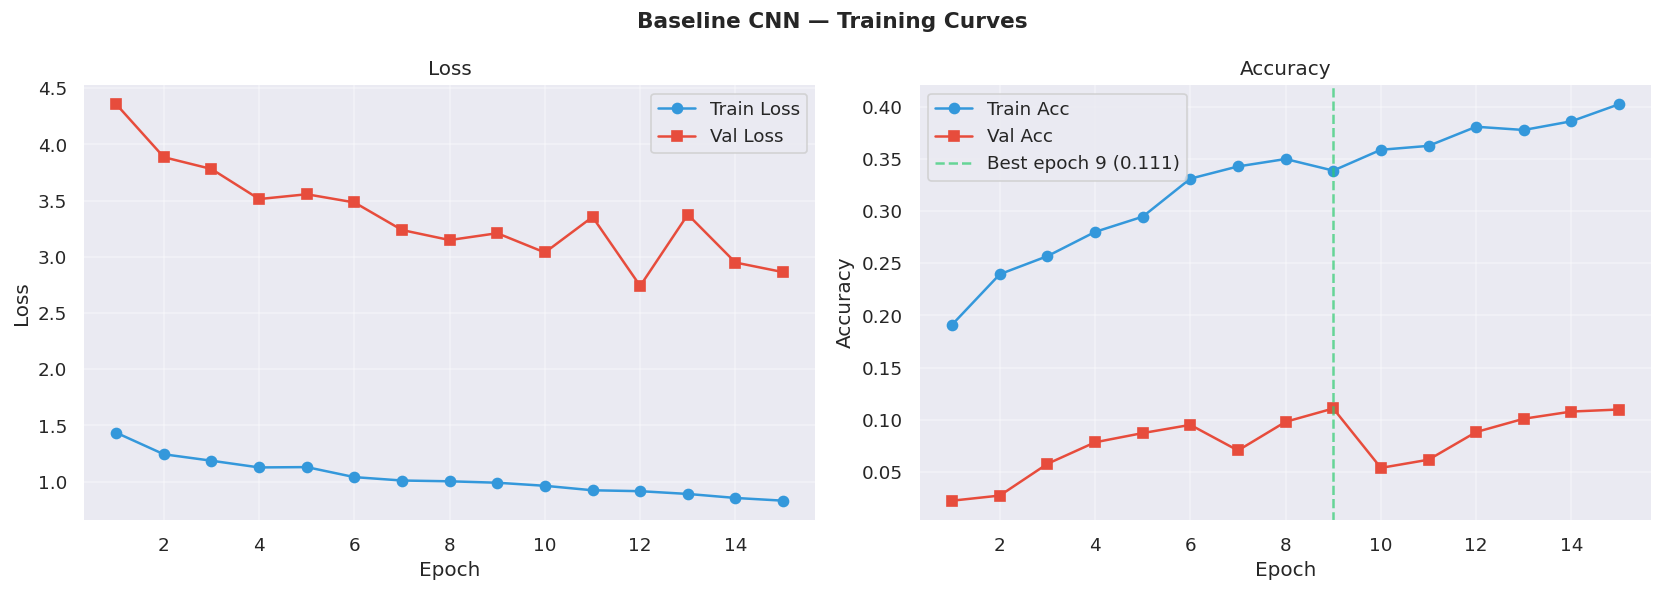

In [13]:
plot_training_curves(
    baseline_history,
    title     = 'Baseline CNN — Training Curves',
    save_path = OUTPUT_DIR / 'baseline_training_curves.png'
)

# CNN Model

### EfficientNet-B0 Transfer Learning

   - Load pretrained EfficientNet-B0 and replace the classifier head.
    - Strategy:
      -  Phase 1: freeze backbone → train only the new head (fast convergence)
       - Phase 2: unfreeze all   → fine-tune end-to-end (higher accuracy)

In [14]:
def build_efficientnet(num_classes, freeze_backbone=True):
    
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier: original outputs 1000 ImageNet classes
    in_features = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )

    return model


# Build model — frozen backbone initially
cnn_model = build_efficientnet(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('EfficientNet-B0 (Phase 1 — frozen backbone):')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}  (new head only)')
print(f'  Frozen parameters    : {frozen_params:,}  (ImageNet backbone)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/hitman/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:02<00:00, 9.91MB/s]


EfficientNet-B0 (Phase 1 — frozen backbone):
  Total parameters     : 4,667,011
  Trainable parameters : 659,463  (new head only)
  Frozen parameters    : 4,007,548  (ImageNet backbone)


### Phase 1: Train Head Only (Frozen Backbone)

In [15]:
# Phase 1 Hyperparameters
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3

cnn_criterion  = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
cnn_optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, cnn_model.parameters()),
    lr=PHASE1_LR, weight_decay=1e-4
)
cnn_scheduler  = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=PHASE1_EPOCHS)
cnn_scaler     = torch.cuda.amp.GradScaler()

cnn_history    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_cnn_acc   = 0.0
best_cnn_wts   = copy.deepcopy(cnn_model.state_dict())

print(f'Phase 1 — Training HEAD only for {PHASE1_EPOCHS} epochs...')
print('─' * 65)

start_time = time.time()
for epoch in range(1, PHASE1_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, cnn_scaler, DEVICE
    )
    v_loss, v_acc, _, _, _ = evaluate(cnn_model, val_loader, cnn_criterion, DEVICE)

    cnn_history['train_loss'].append(t_loss)
    cnn_history['train_acc'].append(t_acc)
    cnn_history['val_loss'].append(v_loss)
    cnn_history['val_acc'].append(v_acc)
    cnn_scheduler.step()

    marker = ''
    if v_acc > best_cnn_acc:
        best_cnn_acc = v_acc
        best_cnn_wts = copy.deepcopy(cnn_model.state_dict())
        torch.save(best_cnn_wts, MODEL_DIR / 'efficientnet_best.pth')
        marker = '  ← best'

    print(f'  Epoch {epoch:>2}/{PHASE1_EPOCHS}  '
          f'| Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  '
          f'| Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}{marker}')

print('─' * 65)
print(f' Phase 1 complete in {(time.time()-start_time)/60:.1f} min')
print(f'   Best Val Accuracy (Phase 1): {best_cnn_acc:.4f}')

Phase 1 — Training HEAD only for 10 epochs...
─────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch  1/10  | Train Loss: 0.8939  Acc: 0.3887  | Val Loss: 2.5768  Acc: 0.1374  ← best


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch  9/10  | Train Loss: 0.4985  Acc: 0.5648  | Val Loss: 2.1126  Acc: 0.3013


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch 10/10  | Train Loss: 0.5025  Acc: 0.5707  | Val Loss: 2.2193  Acc: 0.2777
─────────────────────────────────────────────────────────────────
 Phase 1 complete in 4.2 min
   Best Val Accuracy (Phase 1): 0.3032


### Phase 2: Unfreeze & Fine-Tune End-to-End

In [16]:
# Unfreeze ALL layers
for param in cnn_model.parameters():
    param.requires_grad = True

total_trainable = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Backbone unfrozen — trainable params: {total_trainable:,}')

#  Phase 2 Hyperparameters 
# Use a MUCH smaller LR for the backbone (avoid destroying pretrained features)
PHASE2_EPOCHS = 20

cnn_optimizer_ft = optim.AdamW([
    {'params': cnn_model.features.parameters(), 'lr': 1e-5},     # backbone — very small
    {'params': cnn_model.classifier.parameters(), 'lr': 1e-4},   # head — slightly larger
], weight_decay=1e-4)

cnn_scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
    cnn_optimizer_ft, T_max=PHASE2_EPOCHS, eta_min=1e-7
)
cnn_scaler_ft = torch.cuda.amp.GradScaler()

print(f'\nPhase 2 — Fine-tuning ALL layers for {PHASE2_EPOCHS} epochs...')
print('─' * 65)

start_time = time.time()
for epoch in range(1, PHASE2_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer_ft, cnn_scaler_ft, DEVICE
    )
    v_loss, v_acc, _, _, _ = evaluate(cnn_model, val_loader, cnn_criterion, DEVICE)

    cnn_history['train_loss'].append(t_loss)
    cnn_history['train_acc'].append(t_acc)
    cnn_history['val_loss'].append(v_loss)
    cnn_history['val_acc'].append(v_acc)
    cnn_scheduler_ft.step()

    marker = ''
    if v_acc > best_cnn_acc:
        best_cnn_acc = v_acc
        best_cnn_wts = copy.deepcopy(cnn_model.state_dict())
        torch.save(best_cnn_wts, MODEL_DIR / 'efficientnet_best.pth')
        marker = '  ← best'

    print(f'  Epoch {epoch:>2}/{PHASE2_EPOCHS}  '
          f'| Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  '
          f'| Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}{marker}')

print('─' * 65)
print(f' Phase 2 complete in {(time.time()-start_time)/60:.1f} min')
print(f'  Best Val Accuracy overall: {best_cnn_acc:.4f}')

# Restore best weights
cnn_model.load_state_dict(best_cnn_wts)

Backbone unfrozen — trainable params: 4,667,011

Phase 2 — Fine-tuning ALL layers for 20 epochs...
─────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch  1/20  | Train Loss: 0.4665  Acc: 0.5854  | Val Loss: 2.0061  Acc: 0.3317  ← best


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

...

  Epoch 19/20  | Train Loss: 0.2284  Acc: 0.7232  | Val Loss: 1.6018  Acc: 0.4318  ← best


  Train:   0%|          | 0/251 [00:00<?, ?it/s]

  Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  Epoch 20/20  | Train Loss: 0.2299  Acc: 0.7223  | Val Loss: 1.7205  Acc: 0.4082
─────────────────────────────────────────────────────────────────
 Phase 2 complete in 9.0 min
  Best Val Accuracy overall: 0.4318


<All keys matched successfully>

### EfficientNet Training Curves (Both Phases)

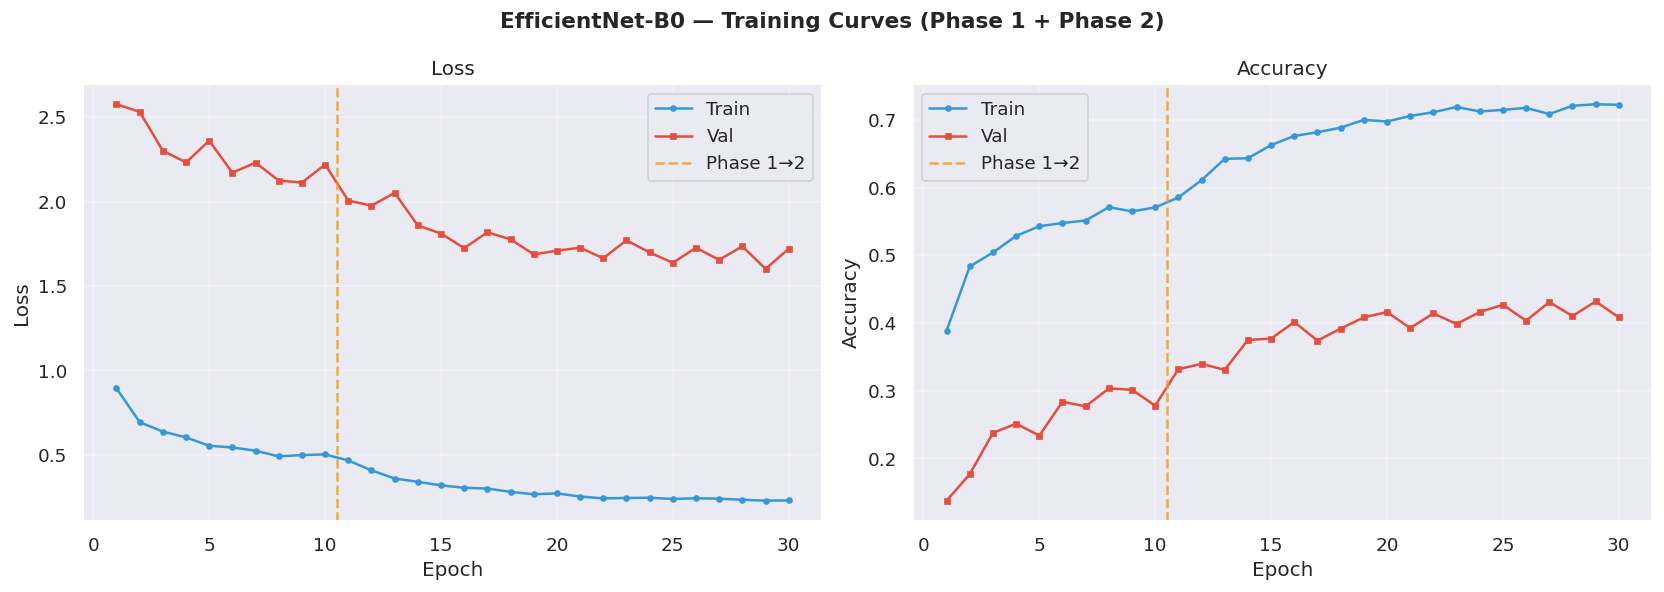

In [17]:
epochs      = range(1, len(cnn_history['train_loss']) + 1)
phase1_end  = PHASE1_EPOCHS
phase2_end  = PHASE1_EPOCHS + PHASE2_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B0 — Training Curves (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')

for ax, metric, ylabel in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Loss', 'Accuracy']
):
    ax.plot(epochs, cnn_history[metric[0]], 'o-', color='#3498db', markersize=3, label='Train')
    ax.plot(epochs, cnn_history[metric[1]], 's-', color='#e74c3c', markersize=3, label='Val')
    ax.axvline(phase1_end + 0.5, color='#f39c12', linestyle='--', linewidth=1.5,
               alpha=0.8, label=f'Phase 1→2')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_training_curves.png', bbox_inches='tight')
plt.show()

# Evaluation

### Inference on Test Set (Both Models)

In [18]:
print('Running inference on test set...')

# Baseline
baseline_model.load_state_dict(torch.load(MODEL_DIR / 'baseline_best.pth', map_location=DEVICE))
_, b_acc, b_preds, b_labels, b_probs = evaluate(baseline_model, test_loader, baseline_criterion, DEVICE)

# EfficientNet
cnn_model.load_state_dict(torch.load(MODEL_DIR / 'efficientnet_best.pth', map_location=DEVICE))
_, c_acc, c_preds, c_labels, c_probs = evaluate(cnn_model, test_loader, cnn_criterion, DEVICE)

# Macro F1
b_f1 = f1_score(b_labels, b_preds, average='macro')
c_f1 = f1_score(c_labels, c_preds, average='macro')

print(f'\n  Baseline CNN    → Test Acc: {b_acc:.4f}  |  Macro F1: {b_f1:.4f}')
print(f'  EfficientNet-B0 → Test Acc: {c_acc:.4f}  |  Macro F1: {c_f1:.4f}')

Running inference on test set...


  Eval :   0%|          | 0/31 [00:00<?, ?it/s]

  Eval :   0%|          | 0/31 [00:00<?, ?it/s]


  Baseline CNN    → Test Acc: 0.0943  |  Macro F1: 0.1009
  EfficientNet-B0 → Test Acc: 0.4191  |  Macro F1: 0.3601


### Classification Report (Per-Class)

In [20]:
print('=' * 70)
print('BASELINE CNN — Classification Report')
print('=' * 70)
print(classification_report(
    b_labels, b_preds,
    target_names=[f'{IDX_TO_CLASS[i]} ({CLASS_NAMES[IDX_TO_CLASS[i]][:15]})'
                  for i in range(NUM_CLASSES)]
))

print('=' * 70)
print('EFFICIENTNET-B0 — Classification Report')
print('=' * 70)
print(classification_report(
    c_labels, c_preds,
    target_names=[f'{IDX_TO_CLASS[i]} ({CLASS_NAMES[IDX_TO_CLASS[i]][:15]})'
                  for i in range(NUM_CLASSES)]
))

BASELINE CNN — Classification Report
                         precision    recall  f1-score   support

akiec (Actinic Keratos)       0.11      0.59      0.19        27
  bcc (Basal Cell Carc)       0.00      0.00      0.00        48
  bkl (Benign Keratosi)       0.29      0.02      0.04       100
    df (Dermatofibroma)       0.04      0.71      0.07        17
         mel (Melanoma)       0.26      0.46      0.33       106
   nv (Melanocytic Nev)       0.00      0.00      0.00       663
 vasc (Vascular Lesion)       0.04      0.87      0.08        15

               accuracy                           0.09       976
              macro avg       0.10      0.38      0.10       976
           weighted avg       0.06      0.09      0.05       976

EFFICIENTNET-B0 — Classification Report
                         precision    recall  f1-score   support

akiec (Actinic Keratos)       0.19      0.63      0.29        27
  bcc (Basal Cell Carc)       0.40      0.75      0.52        48
  bkl (Be

### Confusion metrics

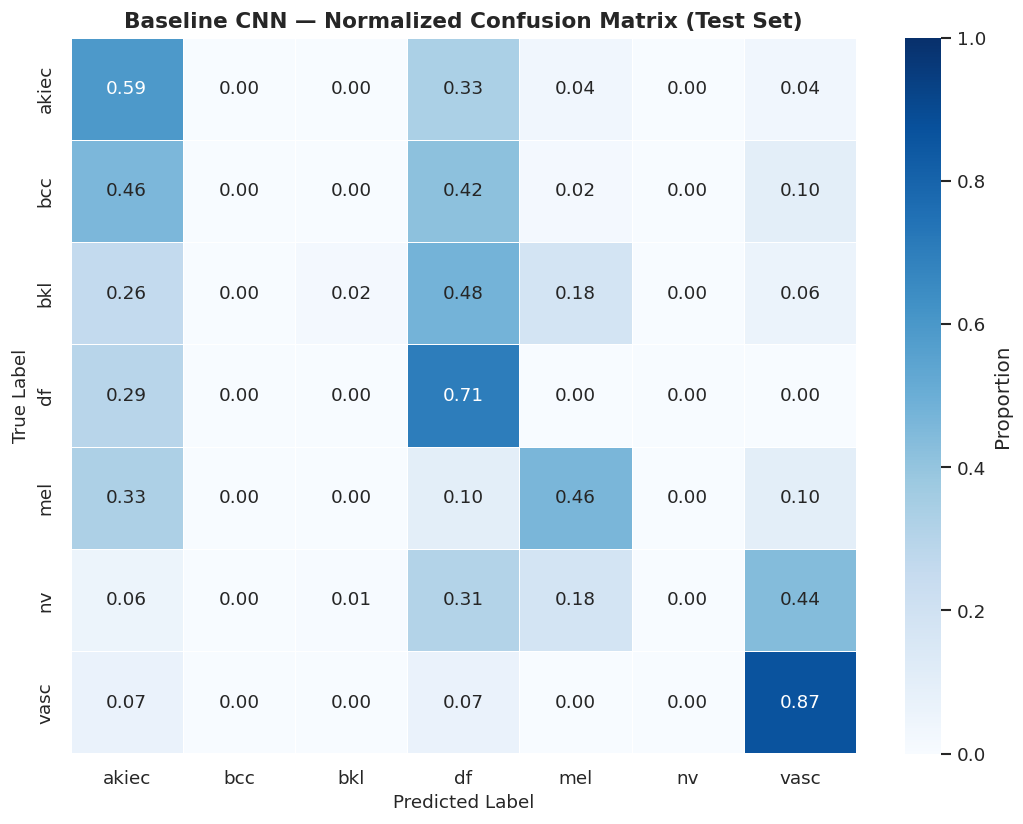

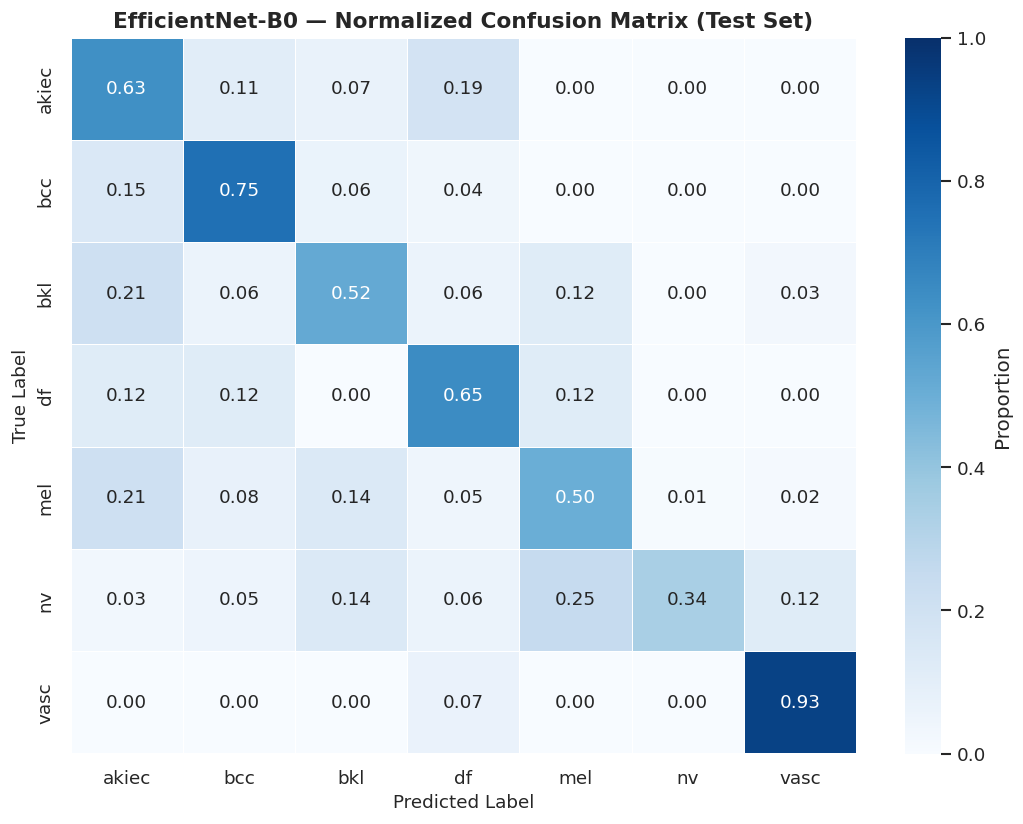

In [22]:
def plot_confusion_matrix(labels, preds, title, save_path, normalize=True):
    cm = confusion_matrix(labels, preds)
    if normalize:
        cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt, vmax = '.2f', 1.0
    else:
        cm_plot = cm
        fmt, vmax = 'd', cm.max()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=SHORT_LABELS, yticklabels=SHORT_LABELS,
                vmin=0, vmax=vmax, linewidths=0.5, linecolor='white',
                ax=ax, cbar_kws={'label': 'Proportion' if normalize else 'Count'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    b_labels, b_preds,
    title     = 'Baseline CNN — Normalized Confusion Matrix (Test Set)',
    save_path = OUTPUT_DIR / 'baseline_confusion_matrix.png'
)

plot_confusion_matrix(
    c_labels, c_preds,
    title     = 'EfficientNet-B0 — Normalized Confusion Matrix (Test Set)',
    save_path = OUTPUT_DIR / 'cnn_confusion_matrix.png'
)

### Per-Class Precision, Recall & F1 Bar Charts

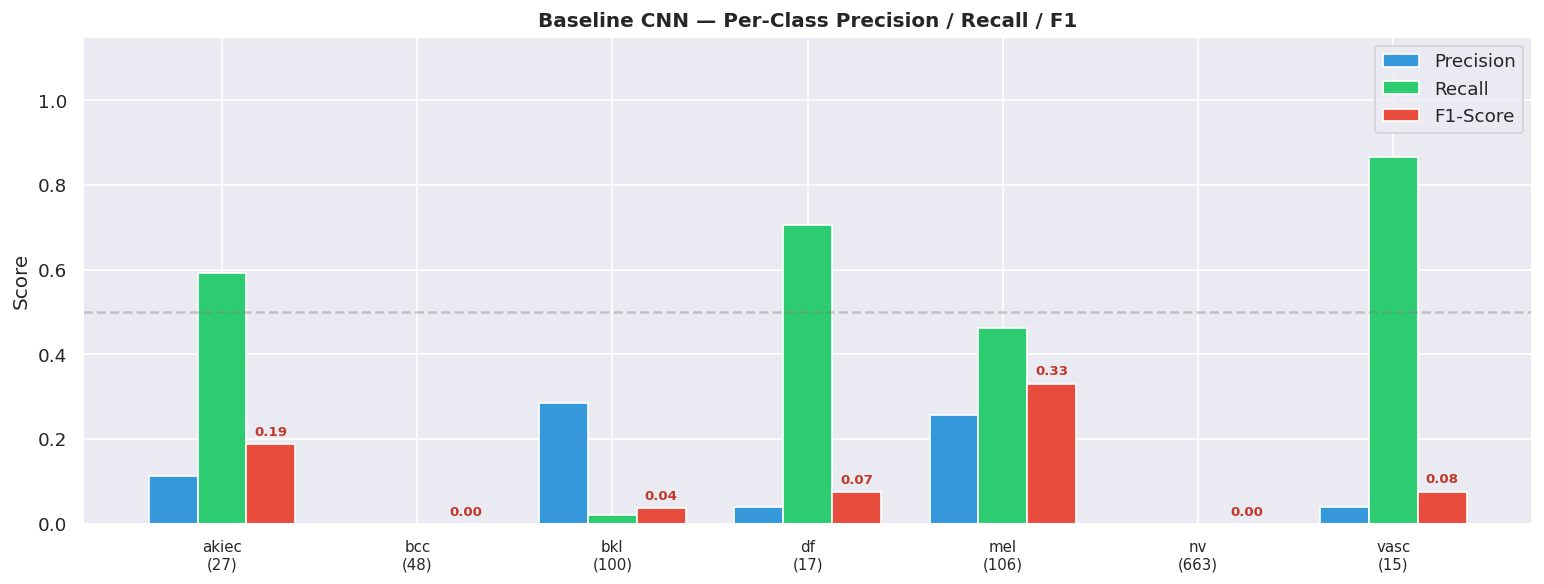

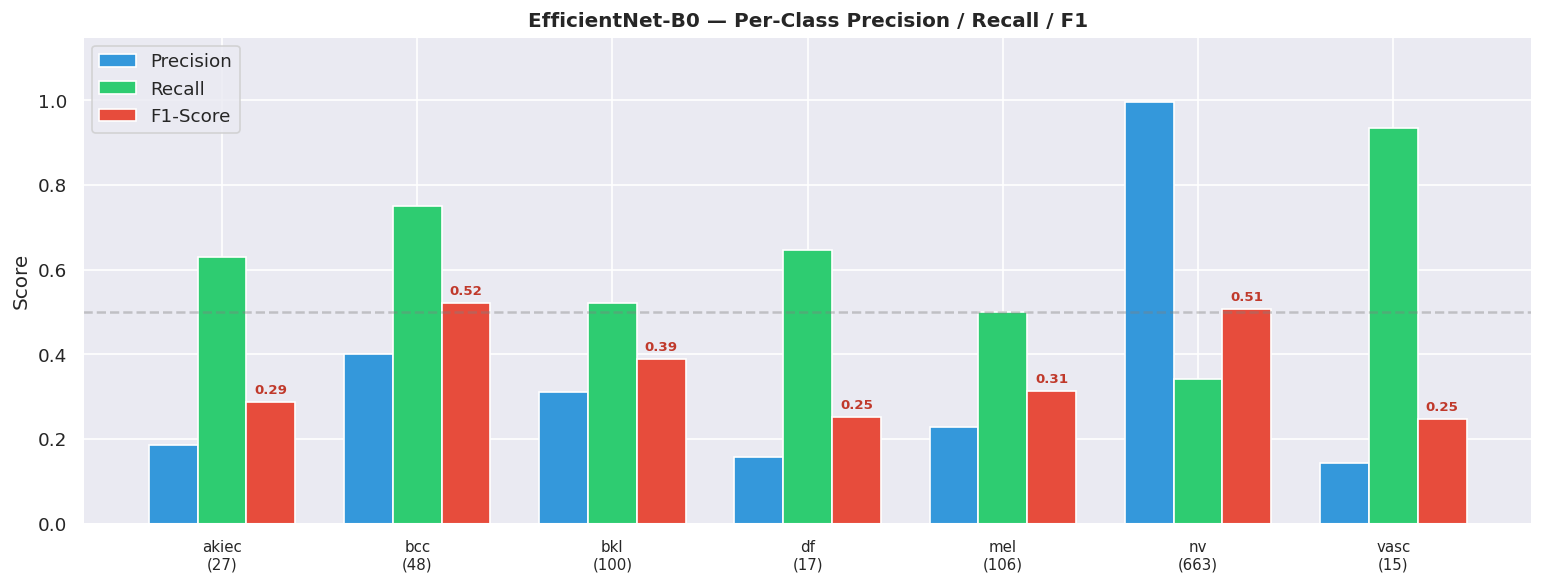

In [23]:
from sklearn.metrics import precision_recall_fscore_support

def plot_per_class_metrics(labels, preds, model_name, save_path):
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_CLASSES))
    )

    x = np.arange(NUM_CLASSES)
    width = 0.25

    fig, ax = plt.subplots(figsize=(13, 5))
    bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db', edgecolor='white')
    bars2 = ax.bar(x,         recall,    width, label='Recall',    color='#2ecc71', edgecolor='white')
    bars3 = ax.bar(x + width, f1,        width, label='F1-Score',  color='#e74c3c', edgecolor='white')

    ax.set_title(f'{model_name} — Per-Class Precision / Recall / F1', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{IDX_TO_CLASS[i]}\n({support[i]})' for i in range(NUM_CLASSES)], fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.legend()
    ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4)

    # Value labels on F1 bars
    for bar, val in zip(bars3, f1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=8, color='#c0392b', fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


plot_per_class_metrics(b_labels, b_preds, 'Baseline CNN',
                       OUTPUT_DIR / 'baseline_per_class_metrics.png')
plot_per_class_metrics(c_labels, c_preds, 'EfficientNet-B0',
                       OUTPUT_DIR / 'cnn_per_class_metrics.png')

### ROC-AUC Curves (One-vs-Rest)

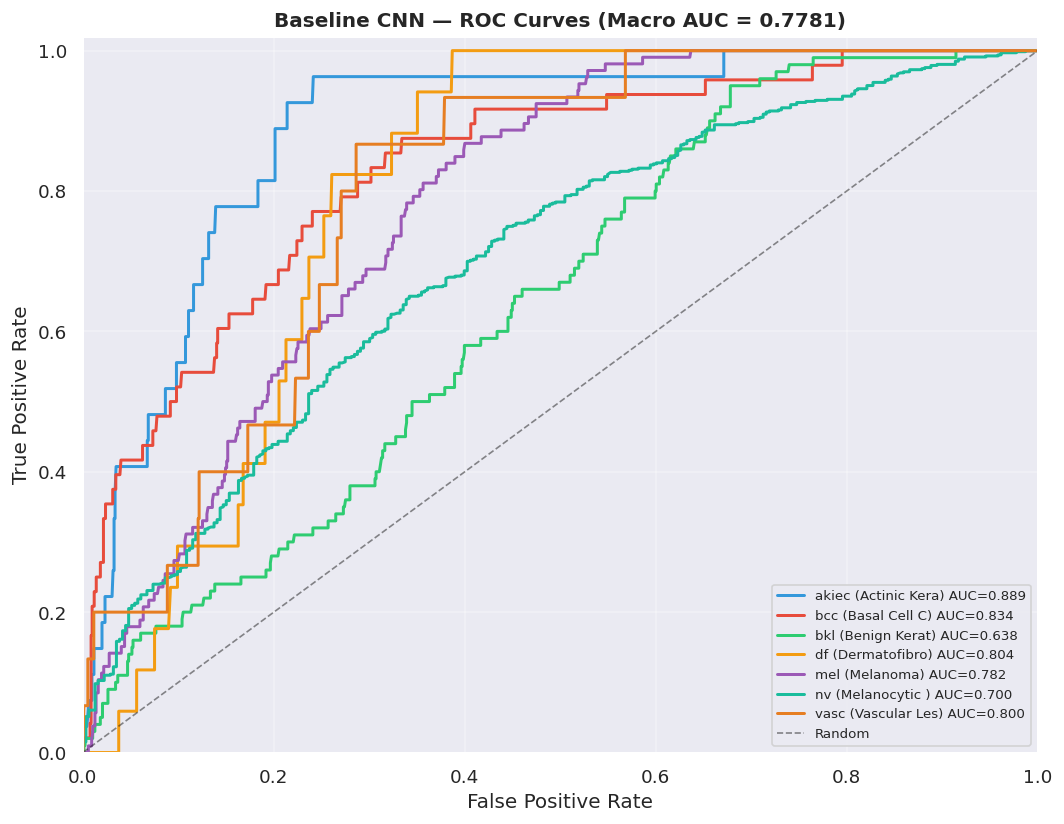

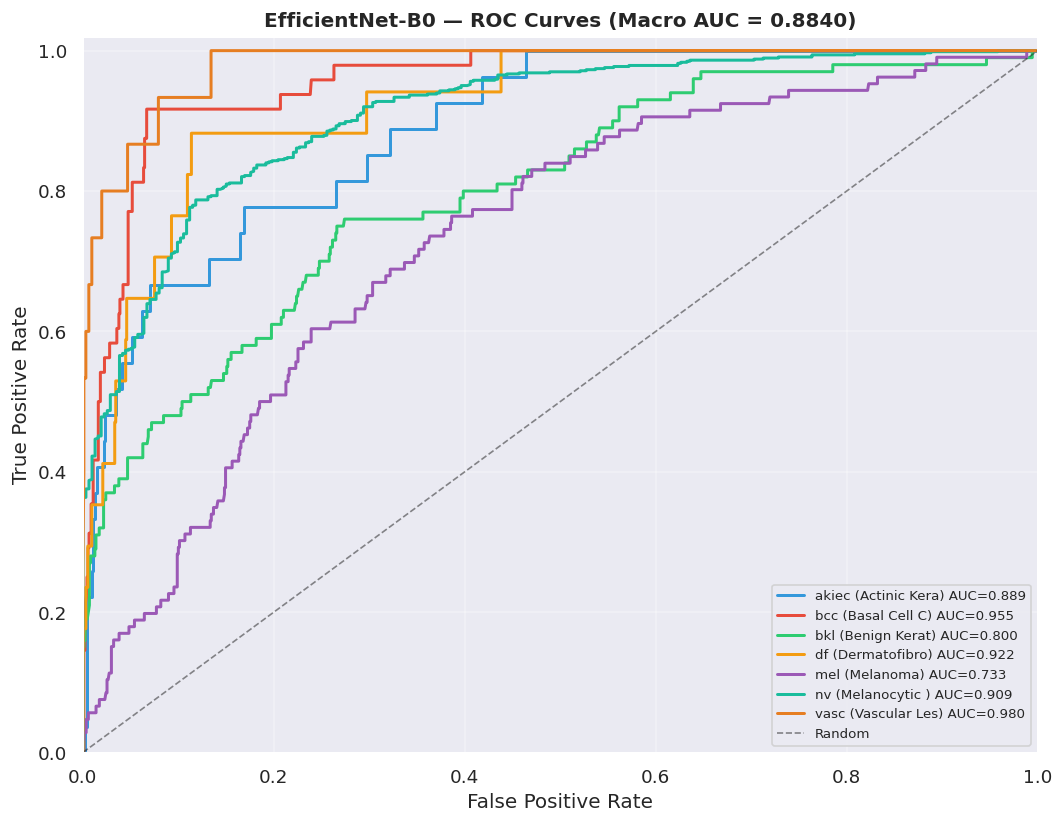

Baseline ROC-AUC (macro)    : 0.7781
EfficientNet ROC-AUC (macro): 0.8840


In [24]:
def plot_roc_curves(labels, probs, model_name, save_path):
    # Binarize labels for one-vs-rest
    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))

    fig, ax = plt.subplots(figsize=(9, 7))

    macro_auc_scores = []
    for i, (color, cls_key) in enumerate(zip(CLASS_COLORS, SHORT_LABELS)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        auc_score   = roc_auc_score(labels_bin[:, i], probs[:, i])
        macro_auc_scores.append(auc_score)
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{cls_key} ({CLASS_NAMES[cls_key][:12]}) AUC={auc_score:.3f}')

    macro_auc = np.mean(macro_auc_scores)
    ax.plot([0,1],[0,1], 'k--', lw=1.0, alpha=0.5, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} — ROC Curves (Macro AUC = {macro_auc:.4f})',
                 fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    return macro_auc


b_auc = plot_roc_curves(b_labels, b_probs, 'Baseline CNN',
                        OUTPUT_DIR / 'baseline_roc_curves.png')
c_auc = plot_roc_curves(c_labels, c_probs, 'EfficientNet-B0',
                        OUTPUT_DIR / 'cnn_roc_curves.png')

print(f'Baseline ROC-AUC (macro)    : {b_auc:.4f}')
print(f'EfficientNet ROC-AUC (macro): {c_auc:.4f}')

### Grad-CAM Visualization

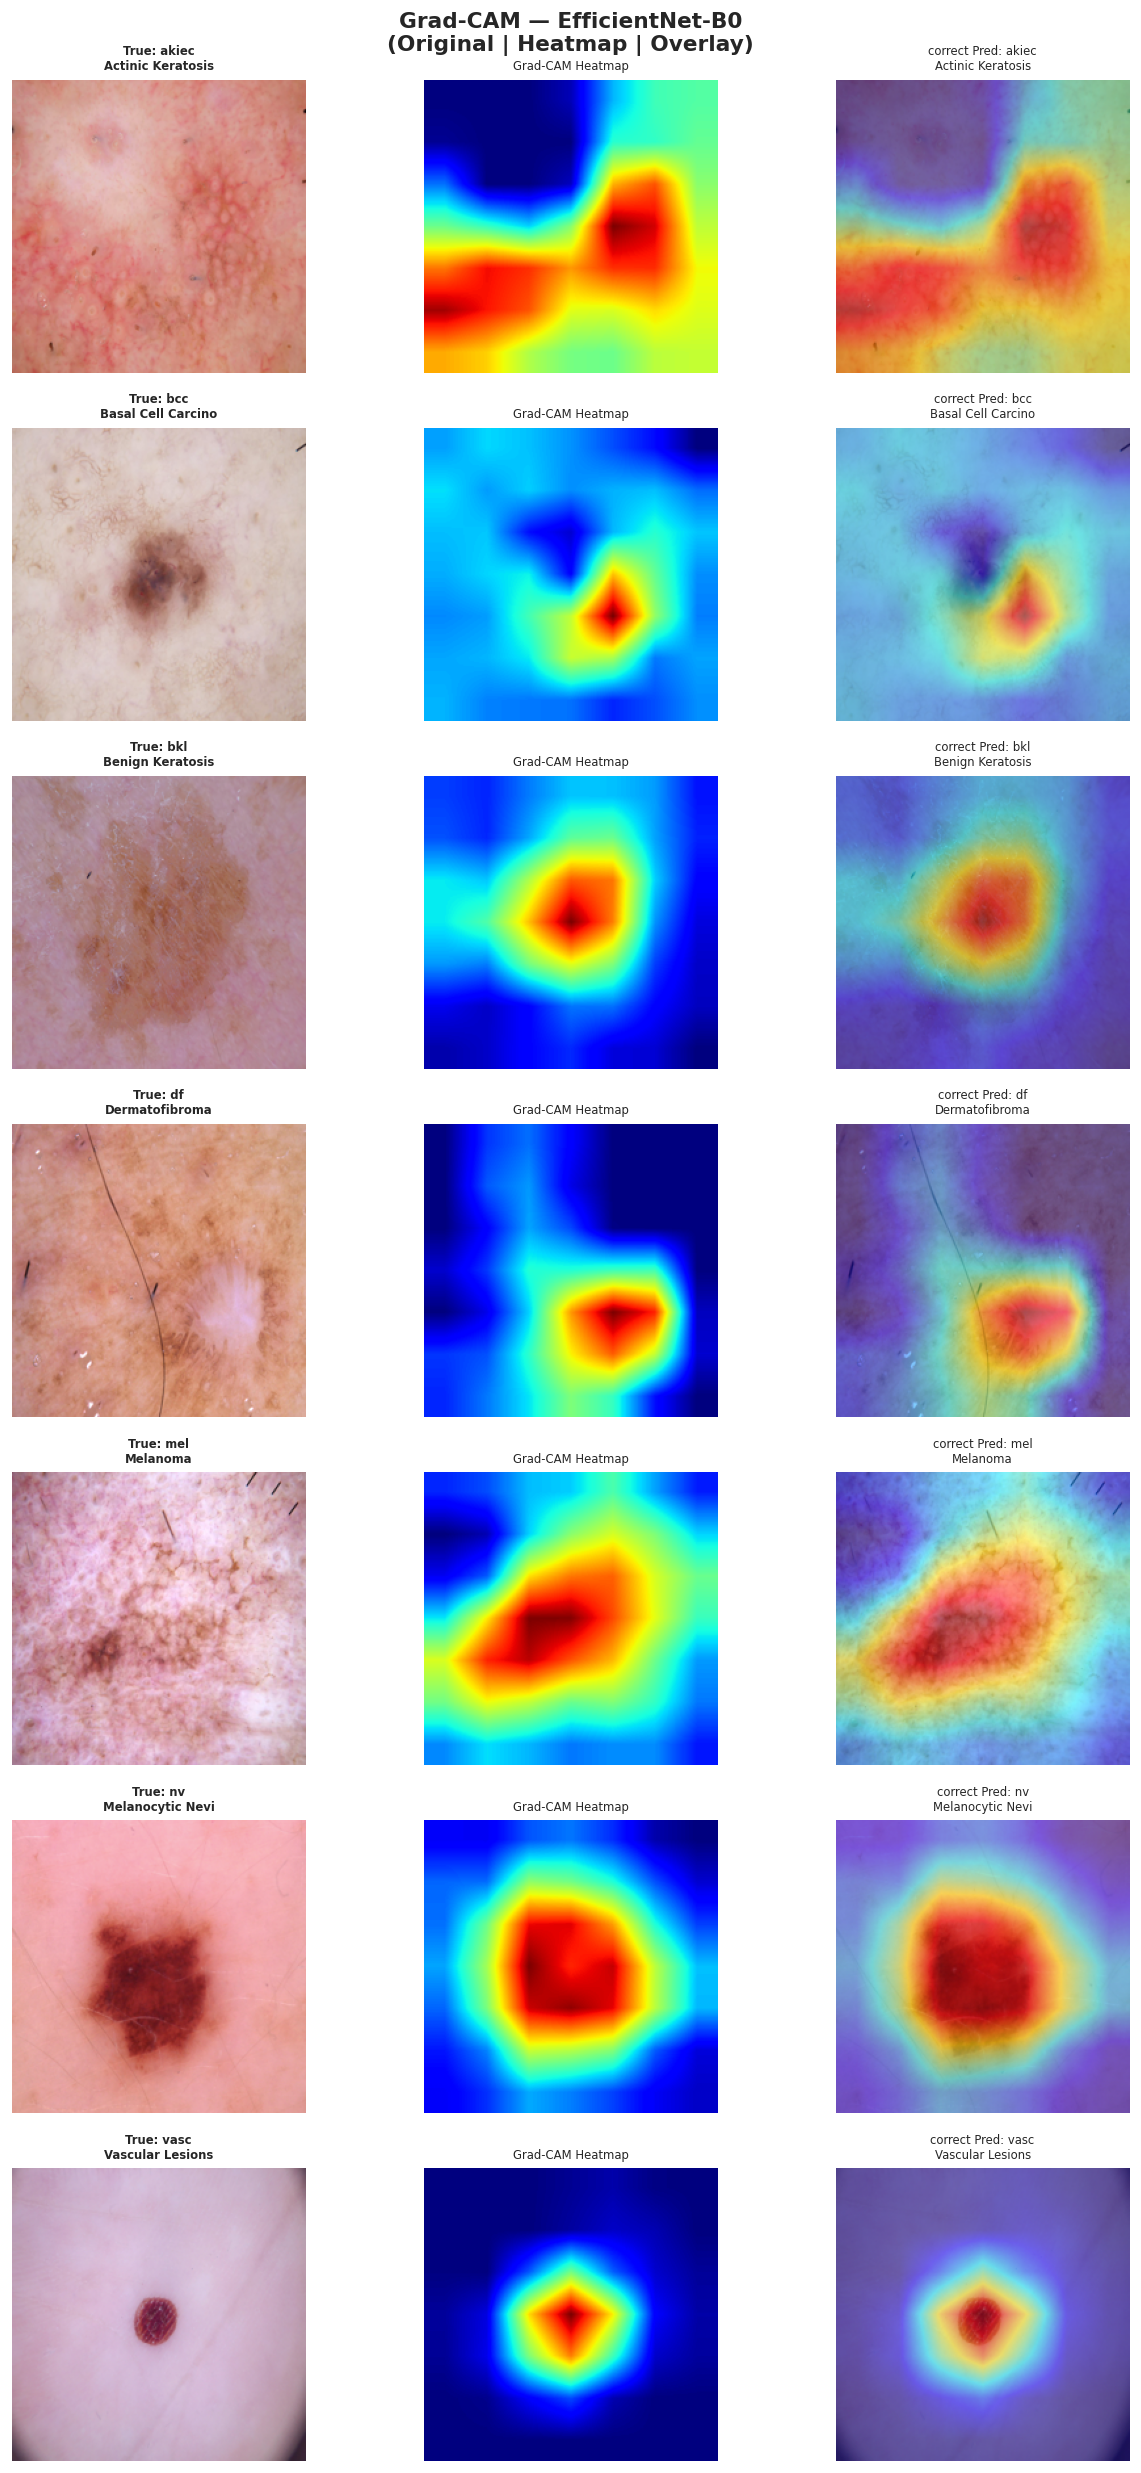

In [25]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Shows WHICH regions of the image the model focused on.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot)

        # Pool gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)

        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class


def overlay_gradcam(image_path, cam, alpha=0.5):
    """Overlay Grad-CAM heatmap onto original image."""
    img = np.array(Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))

    # Resize CAM to image size
    import cv2
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = np.uint8(alpha * heatmap + (1 - alpha) * img)
    return img, cam_resized, overlay


# Target layer: last conv block of EfficientNet-B0
target_layer = cnn_model.features[-1][0]  # last conv block
gradcam      = GradCAM(cnn_model, target_layer)

# Pick 1 sample per class from test set
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(11, NUM_CLASSES * 3))
fig.suptitle('Grad-CAM — EfficientNet-B0\n(Original | Heatmap | Overlay)',
             fontsize=13, fontweight='bold')

for cls_idx in range(NUM_CLASSES):
    cls_key     = IDX_TO_CLASS[cls_idx]
    cls_samples = test_df[test_df['label'] == cls_idx]
    if len(cls_samples) == 0:
        continue
    row       = cls_samples.sample(1, random_state=SEED).iloc[0]
    img_path  = row['image_path']

    # Preprocess image for model
    pil_img    = Image.open(img_path).convert('RGB')
    inp_tensor = val_transforms(pil_img).unsqueeze(0).to(DEVICE)

    cam, pred_cls = gradcam.generate(inp_tensor, target_class=cls_idx)
    orig, heatmap_norm, overlay = overlay_gradcam(img_path, cam)

    pred_name = CLASS_NAMES[IDX_TO_CLASS[pred_cls]]
    true_name = CLASS_NAMES[cls_key]
    correct   = 'correct' if pred_cls == cls_idx else 'incorrect'

    axes[cls_idx, 0].imshow(orig)
    axes[cls_idx, 0].set_title(f'True: {cls_key}\n{true_name[:18]}', fontsize=7, fontweight='bold')
    axes[cls_idx, 0].axis('off')

    axes[cls_idx, 1].imshow(heatmap_norm, cmap='jet')
    axes[cls_idx, 1].set_title('Grad-CAM Heatmap', fontsize=7)
    axes[cls_idx, 1].axis('off')

    axes[cls_idx, 2].imshow(overlay)
    axes[cls_idx, 2].set_title(f'{correct} Pred: {IDX_TO_CLASS[pred_cls]}\n{pred_name[:18]}', fontsize=7)
    axes[cls_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_visualization.png', bbox_inches='tight')
plt.show()

### Misclassification Analysis

EfficientNet misclassified : 567 / 976 test images
Test accuracy              : 0.4191



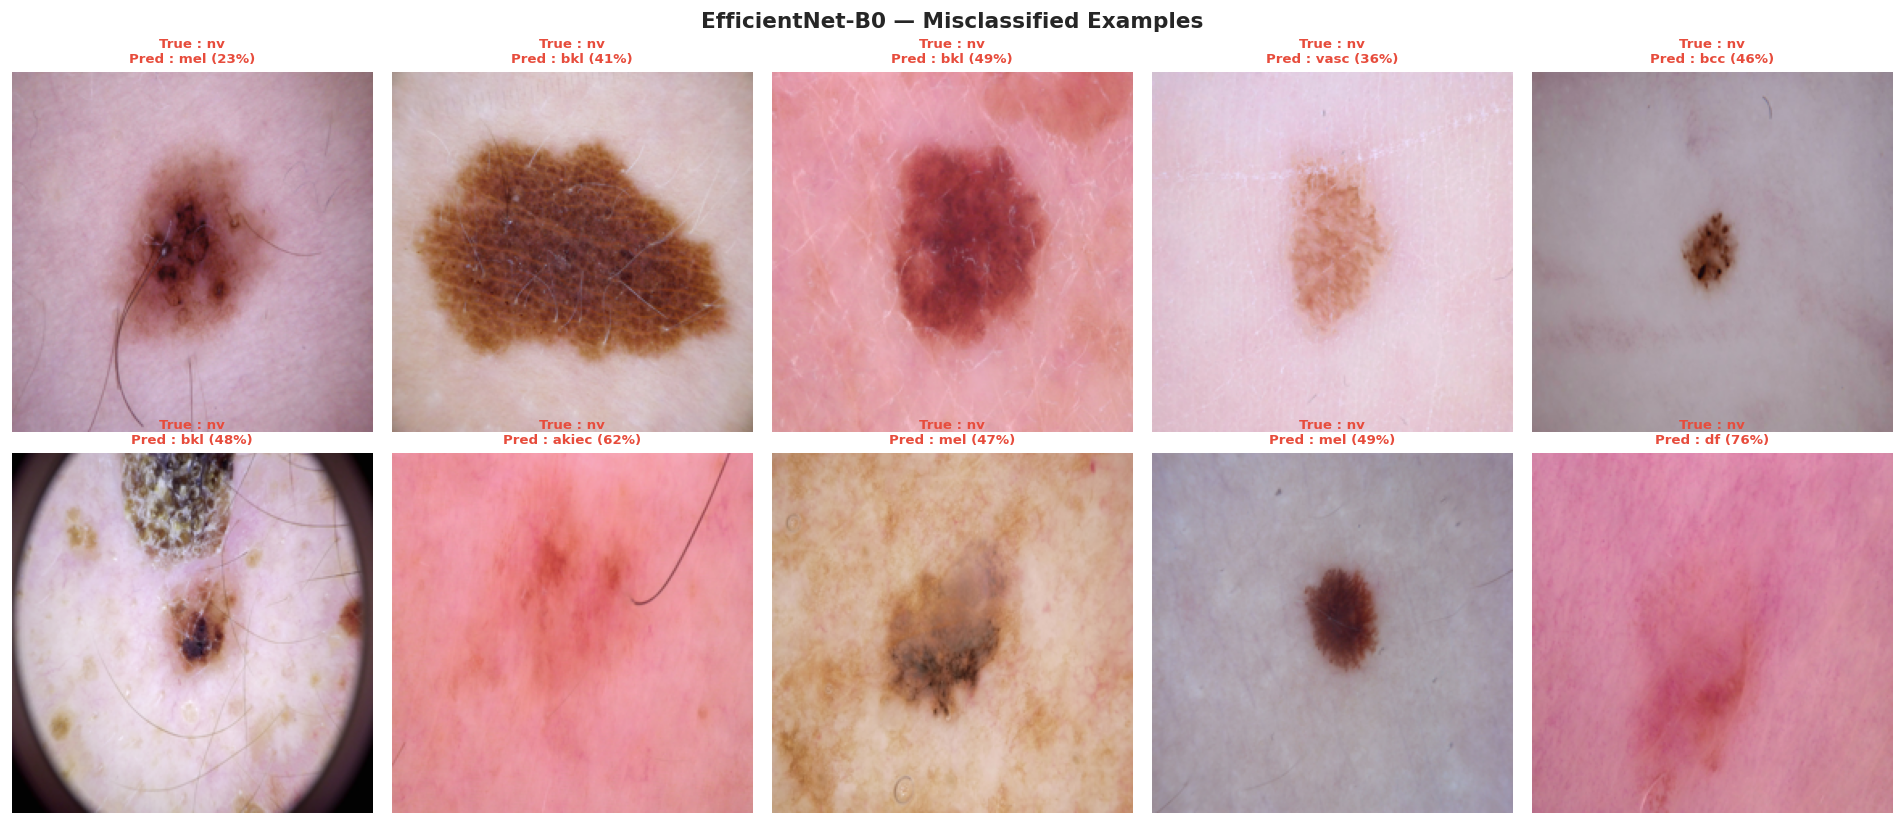

In [26]:
# Find misclassified samples in test set (EfficientNet)
wrong_mask   = c_preds != c_labels
wrong_idx    = np.where(wrong_mask)[0]

print(f'EfficientNet misclassified : {wrong_mask.sum()} / {len(c_labels)} test images')
print(f'Test accuracy              : {1 - wrong_mask.mean():.4f}\n')

# Show 10 wrong predictions with images
N_SHOW = min(10, len(wrong_idx))
sample_wrong = np.random.choice(wrong_idx, N_SHOW, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('EfficientNet-B0 — Misclassified Examples', fontsize=13, fontweight='bold')

for i, (ax, idx) in enumerate(zip(axes.flatten(), sample_wrong)):
    row       = test_df.iloc[idx]
    true_cls  = IDX_TO_CLASS[c_labels[idx]]
    pred_cls  = IDX_TO_CLASS[c_preds[idx]]
    conf      = c_probs[idx][c_preds[idx]] * 100

    img = Image.open(row['image_path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(
        f'True : {true_cls}\nPred : {pred_cls} ({conf:.0f}%)',
        fontsize=8,
        color='#e74c3c',
        fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_misclassified.png', bbox_inches='tight')
plt.show()

### Model Comparison Table


  MODEL COMPARISON — TEST SET
                 Baseline CNN  EfficientNet-B0  Δ Improvement
Metric                                                       
Accuracy               0.0943           0.4191         0.3248
Macro F1               0.1009           0.3601         0.2592
Weighted F1            0.0474           0.4607         0.4133
Macro Precision        0.1049           0.3459         0.2410
Macro Recall           0.3782           0.6173         0.2391
Macro ROC-AUC          0.7781           0.8840         0.1059


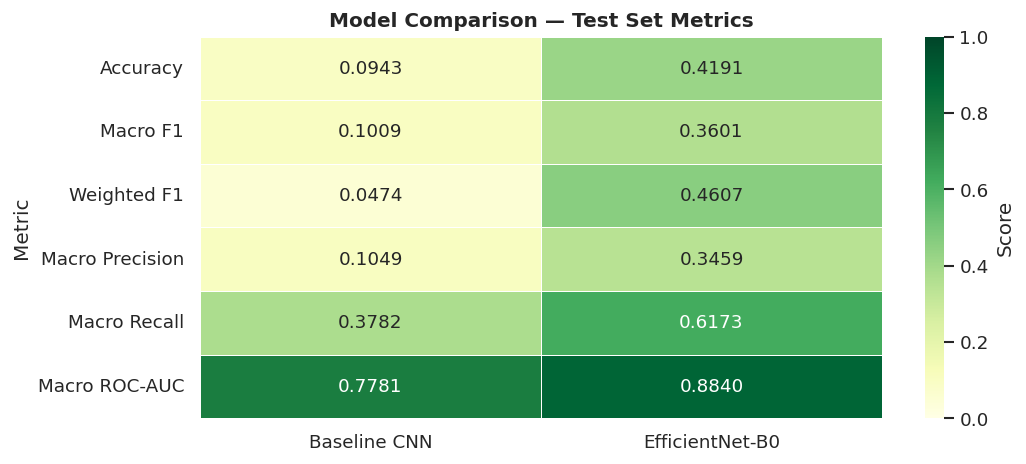

In [27]:
from sklearn.metrics import precision_recall_fscore_support

def get_summary(labels, preds, probs):
    acc   = accuracy_score(labels, preds)
    macro_f1  = f1_score(labels, preds, average='macro')
    weighted_f1 = f1_score(labels, preds, average='weighted')
    labels_bin  = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    auc   = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    prec, rec, _, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {
        'Accuracy'      : round(acc, 4),
        'Macro F1'      : round(macro_f1, 4),
        'Weighted F1'   : round(weighted_f1, 4),
        'Macro Precision': round(prec, 4),
        'Macro Recall'  : round(rec, 4),
        'Macro ROC-AUC' : round(auc, 4),
    }

b_summary = get_summary(b_labels, b_preds, b_probs)
c_summary = get_summary(c_labels, c_preds, c_probs)

comparison_df = pd.DataFrame({
    'Metric'              : list(b_summary.keys()),
    'Baseline CNN'        : list(b_summary.values()),
    'EfficientNet-B0'     : list(c_summary.values()),
    'Δ Improvement'       : [round(c - b, 4) for b, c in
                             zip(b_summary.values(), c_summary.values())]
})
comparison_df = comparison_df.set_index('Metric')

print('\n' + '='*60)
print('  MODEL COMPARISON — TEST SET')
print('='*60)
print(comparison_df.to_string())
print('='*60)

# Save as CSV
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv')

# Visual heatmap table
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    comparison_df[['Baseline CNN','EfficientNet-B0']].astype(float),
    annot=True, fmt='.4f', cmap='YlGn',
    vmin=0, vmax=1, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Score'}
)
ax.set_title('Model Comparison — Test Set Metrics', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_heatmap.png', bbox_inches='tight')
plt.show()

## Save Final Model

In [28]:
torch.save({
    'model_state_dict' : cnn_model.state_dict(),
    'class_to_idx'     : CLASS_TO_IDX,
    'idx_to_class'     : IDX_TO_CLASS,
    'class_names'      : CLASS_NAMES,
    'num_classes'      : NUM_CLASSES,
    'img_size'         : IMG_SIZE,
    'imagenet_mean'    : IMAGENET_MEAN,
    'imagenet_std'     : IMAGENET_STD,
    'architecture'     : 'efficientnet_b0',
    'test_accuracy'    : c_summary['Accuracy'],
    'test_macro_f1'    : c_summary['Macro F1'],
    'test_roc_auc'     : c_summary['Macro ROC-AUC'],
}, MODEL_DIR / 'efficientnet_inference.pth')

print(' Inference bundle saved to:', MODEL_DIR / 'efficientnet_inference.pth')

# List all saved files
print('\n models/ directory:')
for f in sorted(MODEL_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f.name:<40} {size_mb:.1f} MB')

 Inference bundle saved to: models/efficientnet_inference.pth

 models/ directory:
   baseline_best.pth                        1.7 MB
   efficientnet_best.pth                    19.0 MB
   efficientnet_inference.pth               19.0 MB


# summary

In [30]:
print('═' * 65)
print('  HAM10000 — NOTEBOOK 2 COMPLETE')
print('═' * 65)
print()
print('  Models Trained:')
print(f'    Baseline CNN     → Acc: {b_summary["Accuracy"]:.4f}  F1: {b_summary["Macro F1"]:.4f}  AUC: {b_summary["Macro ROC-AUC"]:.4f}')
print(f'    EfficientNet-B0  → Acc: {c_summary["Accuracy"]:.4f}  F1: {c_summary["Macro F1"]:.4f}  AUC: {c_summary["Macro ROC-AUC"]:.4f}')
print()
print('  Evaluation Artifacts:')
artifacts = [
    'baseline_training_curves.png',
    'cnn_training_curves.png',
    'baseline_confusion_matrix.png',
    'cnn_confusion_matrix.png',
    'baseline_per_class_metrics.png',
    'cnn_per_class_metrics.png',
    'baseline_roc_curves.png',
    'cnn_roc_curves.png',
    'gradcam_visualization.png',
    'cnn_misclassified.png',
    'model_comparison_heatmap.png',
    'model_comparison.csv',
]
for a in artifacts:
    print(f' outputs/{a}')
print()
print('  Saved Models:')
print('      models/baseline_best.pth')
print('      models/efficientnet_best.pth')
print('      models/efficientnet_inference.pth ')
print()
print('═' * 65)

═════════════════════════════════════════════════════════════════
  HAM10000 — NOTEBOOK 2 COMPLETE
═════════════════════════════════════════════════════════════════

  Models Trained:
    Baseline CNN     → Acc: 0.0943  F1: 0.1009  AUC: 0.7781
    EfficientNet-B0  → Acc: 0.4191  F1: 0.3601  AUC: 0.8840

  Evaluation Artifacts:
 outputs/baseline_training_curves.png
 outputs/cnn_training_curves.png
 outputs/baseline_confusion_matrix.png
 outputs/cnn_confusion_matrix.png
 outputs/baseline_per_class_metrics.png
 outputs/cnn_per_class_metrics.png
 outputs/baseline_roc_curves.png
 outputs/cnn_roc_curves.png
 outputs/gradcam_visualization.png
 outputs/cnn_misclassified.png
 outputs/model_comparison_heatmap.png
 outputs/model_comparison.csv

  Saved Models:
      models/baseline_best.pth
      models/efficientnet_best.pth
      models/efficientnet_inference.pth 

═════════════════════════════════════════════════════════════════
